# Strong coupling expansion
Compute the average denstity $$\langle n \rangle = -\frac{\partial}{\partial \mu} \Omega$$
where $\Omega = -k_BT \ln Z$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import h5py
from robustpade import pade_approx_batch

## Atomic limit exact results for order 0 and 2 

In [49]:
def Z_atomic(U:float, beta:float, mu:float):
    return 1 + 2*np.exp(beta*mu) + np.exp(-beta*(U-2*mu))


def n_0(U:float, beta:float, mu:float):

    Zat = Z_atomic(U, beta, mu)
    return 2/Zat*(np.exp(beta*mu) + np.exp(-beta*(U-2*mu))) 


def dZ_dmu(U:float, beta:float, mu:float):

    return 2*beta*np.exp(beta*mu)+ 2*beta*np.exp(-beta*(U-2*mu))


def n_2(U:float, beta:float, mu:float):

    Zat = Z_atomic(U, beta, mu)

    fact = np.exp(beta*mu)/Zat**2
    A = beta**2/2*(1+np.exp(-beta*(U-2*mu)))
    B = 2*beta/U*np.exp(-beta*(U/2-mu))*np.sinh(beta*U/2)

    dfact = (Zat**2 * beta * np.exp(beta*mu) - 2 * Zat * np.exp(beta*mu) * dZ_dmu(U, beta, mu)) / Zat**4
    dA = beta**3 * np.exp(-beta*(U-2*mu))
    dB = 2*beta**2/U*np.exp(-beta*(U/2-mu))*np.sinh(beta*U/2)

    #return -2/beta*fact*(A+B)*4 #factor 2 for spin and 2 for sites!

    return -2/beta* (dfact*(A+B) + fact*(dA+dB))*4


## Load files 

In [55]:
def load_data(U,beta, alpha):

    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_density_order_4_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        mus = f['mu_list'][:]
        a_4 = f['mean_list'][:]
        errors_4 = f['error_list'][:]
    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_density_order_6_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        a_6 = f['mean_list'][:]
        errors_6 = f['error_list'][:]


    partial_sum_4 = n_0(U, beta, mus) -n_2(U, beta, mus) -a_4
    partial_sum_6 = partial_sum_4 -a_6



    return mus, partial_sum_4, partial_sum_6, a_4, a_6, errors_4, errors_6


def load_data_single(U,beta, alpha, order):

    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_density_order_{order}_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        mus = f['mu_list'][:]
        a_order = f['mean_list'][:]
        errors_order = f['error_list'][:]

    return mus, a_order, errors_order


## Compare with CDet and AFQMC $U=8$, $\beta=2.0$

In [56]:
cdet_mus = np.array([1.0, 1.5, 2.0])
cdet_n = np.array([0.761236, 0.838576, 0.905056])

afqmc_mus = np.array([2.0,2.5,3.0])
afqmc_n = np.array([8.9905500e-01, 9.4684639e-01, 9.7637588e-01])

In [57]:
U = 8.0
beta = 2.0
alpha = 0.01
mus, sum_4, sum_6, a_4, a_6, err_4, err_6 = load_data(U=U, beta=beta, alpha=alpha)

In [58]:
error_sum_4 = err_4
error_sum_6 = np.sqrt(err_4**2 + err_6**2)
coeffs = [n_0(U,beta,mus), n_2(U,beta,mus), a_4, a_6]

pade_21 = pade_approx_batch(coeffs, (2,1))(1.0).real
pade_12 = pade_approx_batch(coeffs, (1,2))(1.0).real

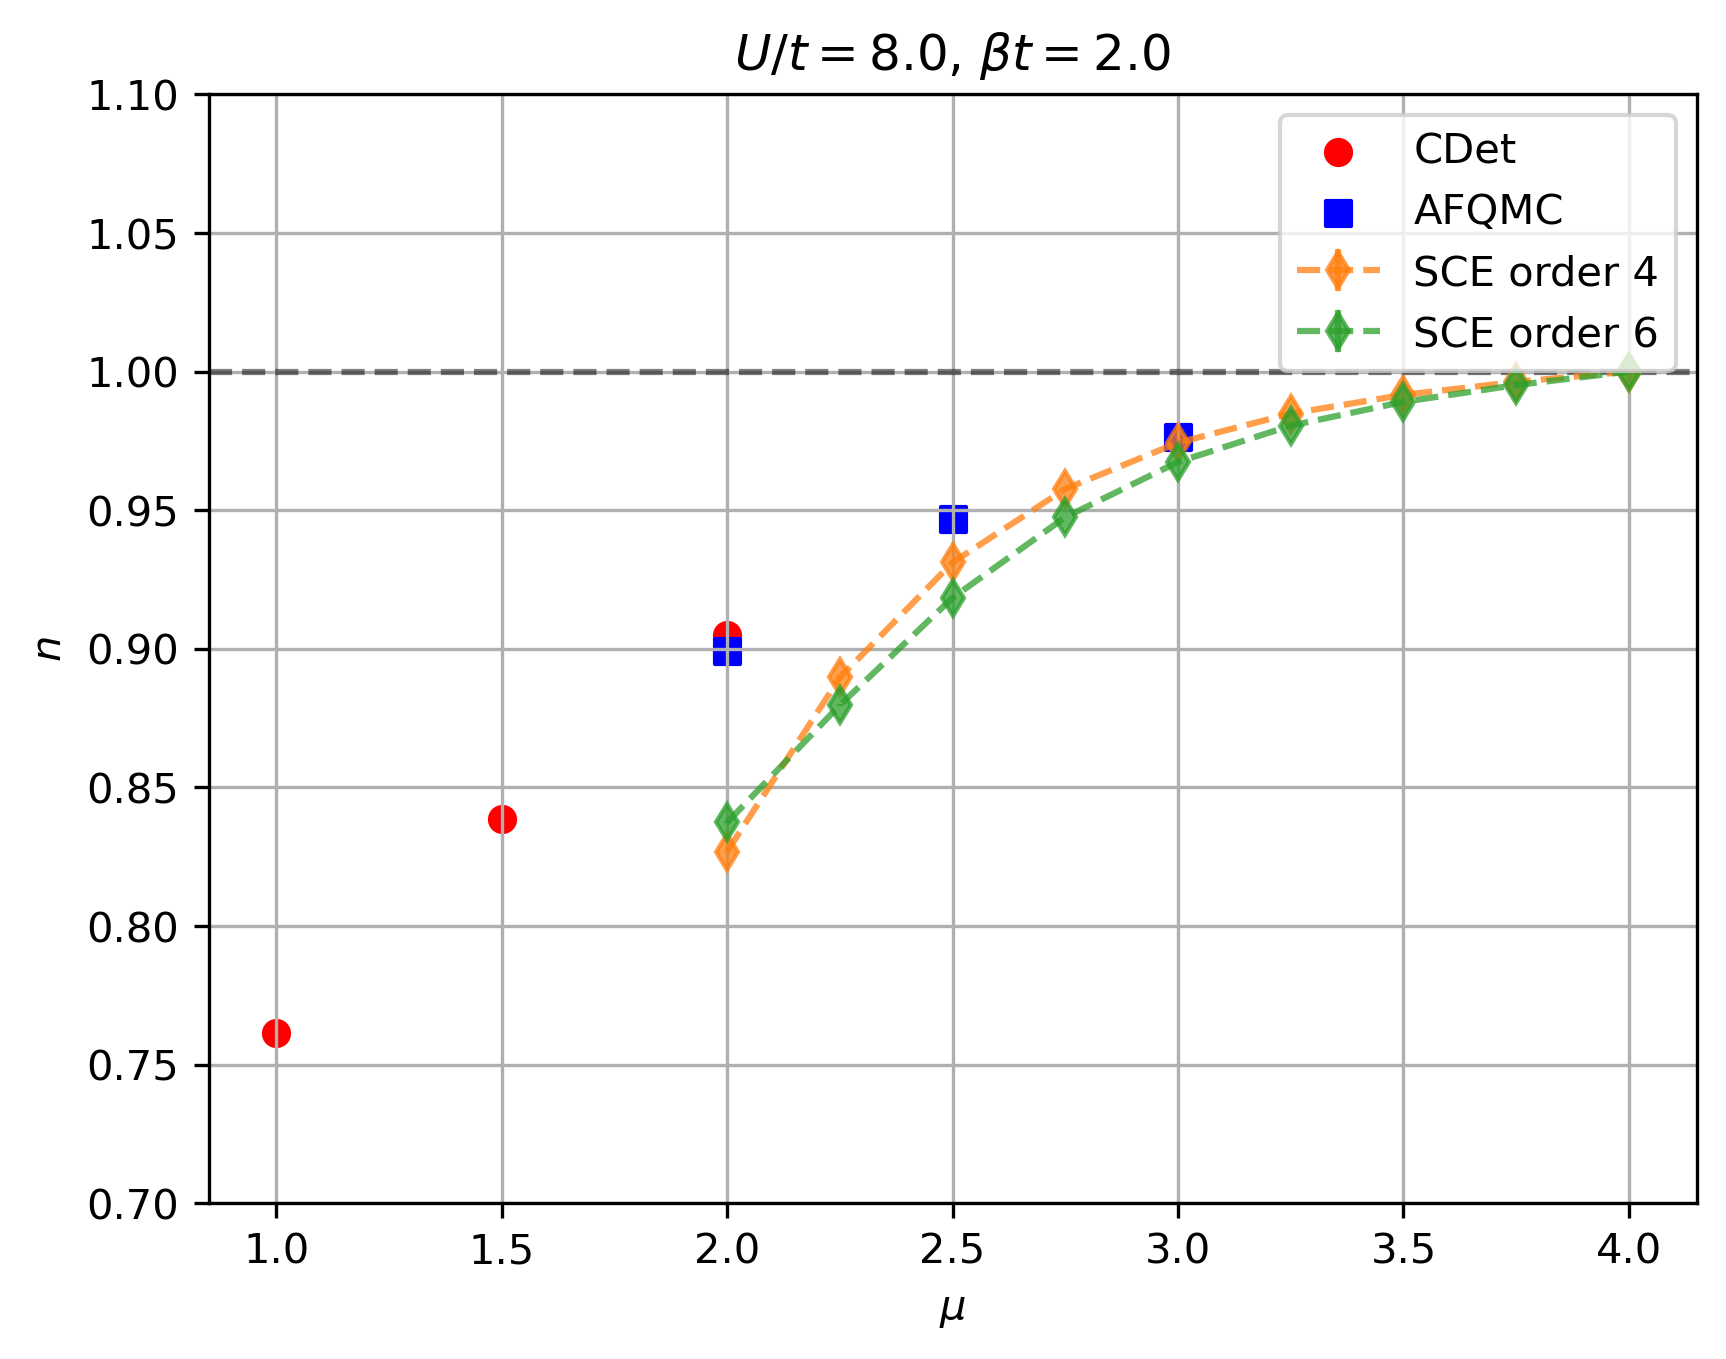

In [59]:
plt.scatter(cdet_mus, cdet_n, label='CDet', color='red')
plt.scatter(afqmc_mus, afqmc_n, label='AFQMC', color='blue', marker = 's')

plt.errorbar(mus, sum_4, yerr=error_sum_4, label='SCE order 4', marker='d', color='tab:orange', linestyle='--', alpha=0.75)
plt.errorbar(mus, sum_6, yerr=error_sum_6, label='SCE order 6', marker='d', color='tab:green', linestyle='--', alpha=0.75)
plt.legend()
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5)

plt.ylim(0.7, 1.1)

plt.xlabel(r'$\mu$')
plt.ylabel(r'$n$')
plt.title(rf'$U/t={U}$, $\beta t={beta}$')
plt.grid(True)

In [36]:
n_2(U=8.0, beta=2.0, mu=4.0)

np.float64(1.1102230246251565e-16)

In [37]:
a_4[-1], mus[-1]

(np.float64(1.4629575792927418e-05), np.float64(4.0))

## $U=8.0$, $\beta=1.0$

In [60]:
U = 8.0
beta = 1.0
alpha = 0.01
mus, sum_4, sum_6, a_4, a_6, err_4, err_6 = load_data(U=U, beta=beta, alpha=alpha)

In [61]:
#load order 8
mus_8, a_8, err_8 = load_data_single(U=U, beta=beta, alpha=alpha, order=8)

In [71]:
mus_8, a_8, err_8 = load_data_single(U=U, beta=beta, alpha=alpha, order=8)
sum_8 = sum_6 -a_8
error_sum_4 = err_4
error_sum_6 = np.sqrt(err_4**2 + err_6**2)
error_sum_8 = np.sqrt(err_4**2 + err_6**2 + err_8**2)
coeffs = [n_0(U,beta,mus), -n_2(U,beta,mus), -a_4, -a_6, -a_8]

padé_23 = pade_approx_batch(coeffs, (2,3))(1.0).real
padé_32 = pade_approx_batch(coeffs, (3,2))(1.0).real
padé_41 = pade_approx_batch(coeffs, (4,1))(1.0).real
padé_14 = pade_approx_batch(coeffs, (1,4))(1.0).real

In [72]:
cdet_data = np.loadtxt('/Users/louissharma/Desktop/results_sc/benchmark/cdet_density_U=8.0_beta=1.0.dat')
cdet_mus = cdet_data[:,0]
cdet_n = cdet_data[:,1]

In [73]:
idx = np.where(cdet_mus==2.0)[0][0]
print(idx)
cdet_mus = cdet_mus[idx:]
cdet_n = cdet_n[idx:]

10


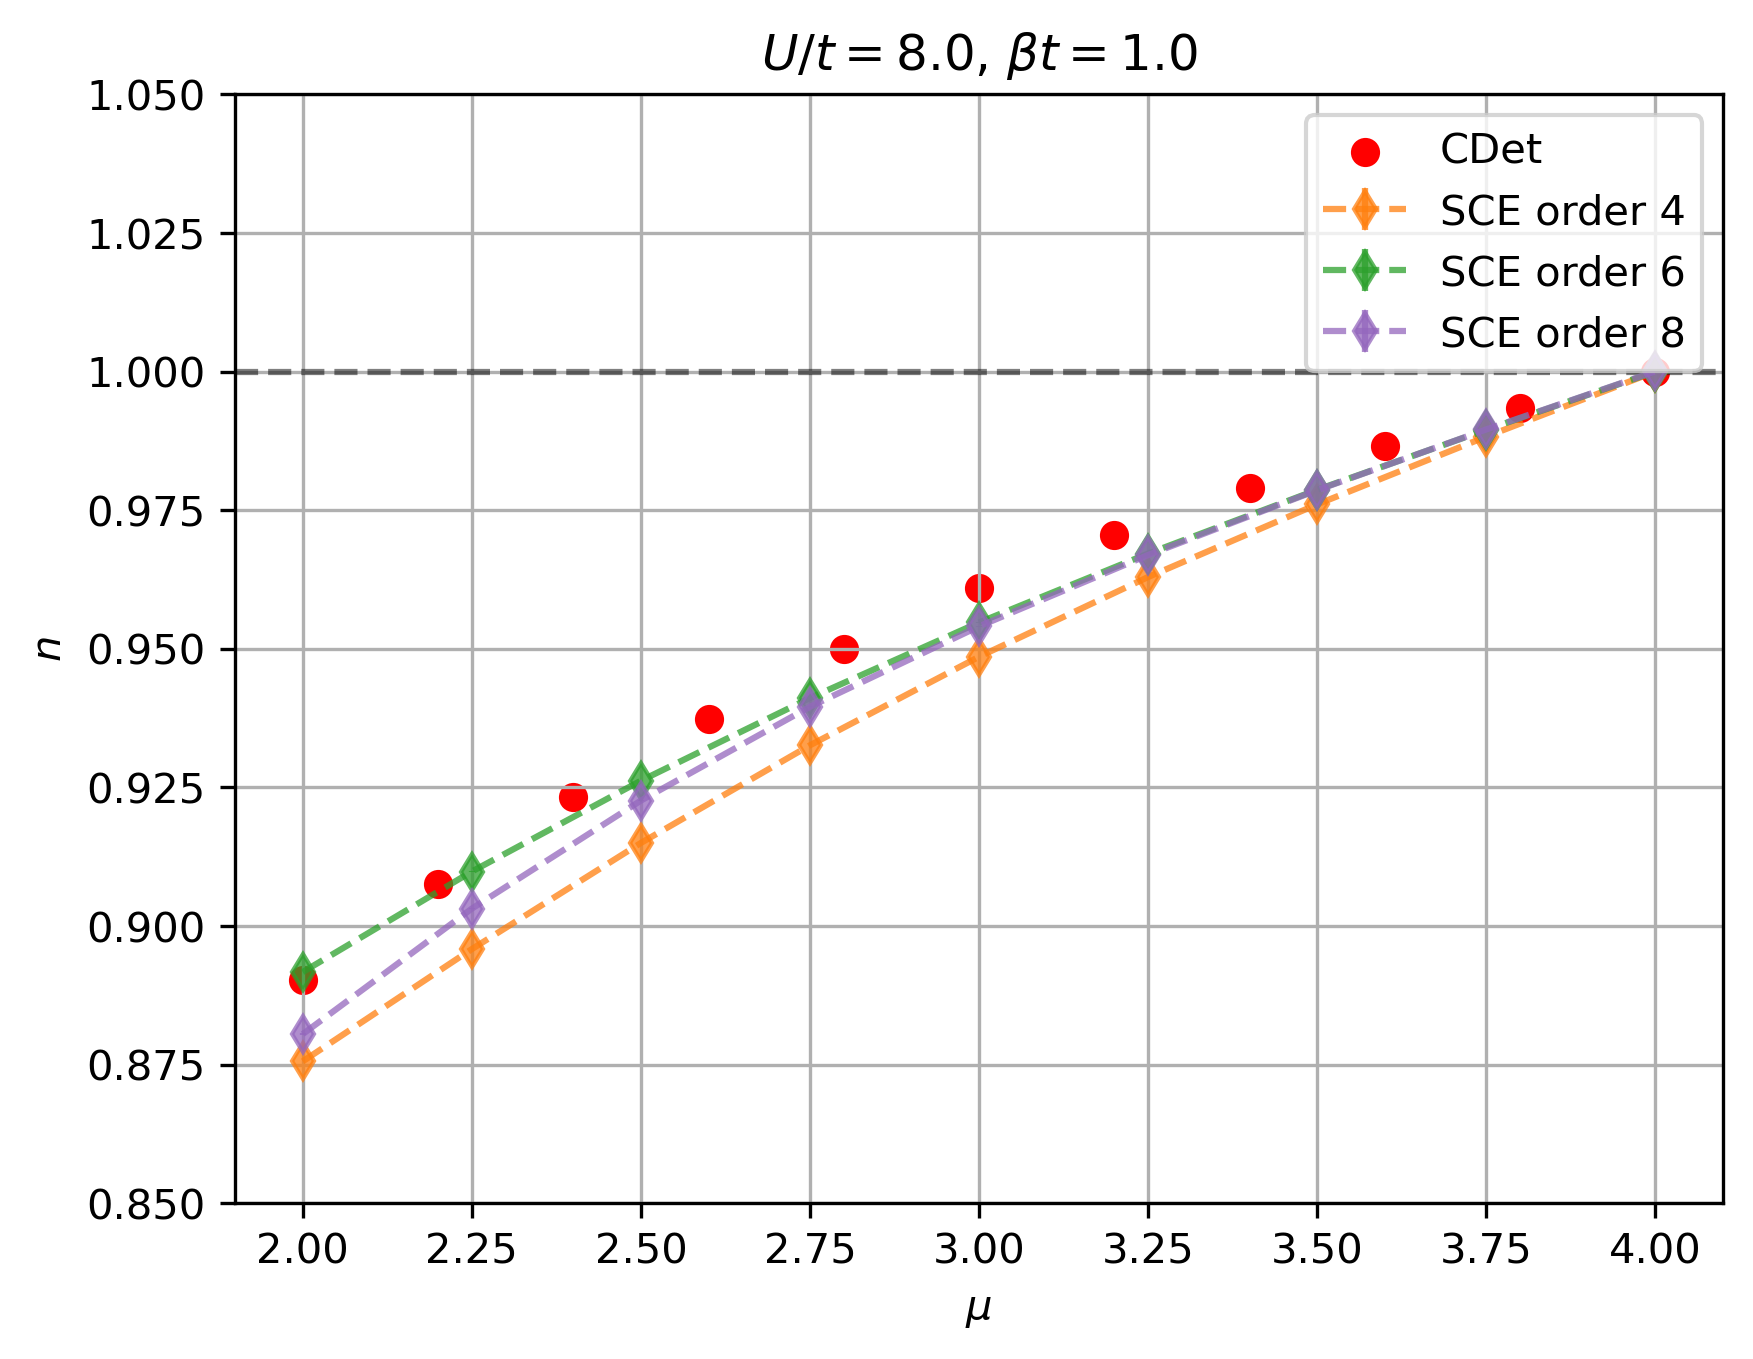

In [77]:
plt.errorbar(mus, sum_4, yerr=error_sum_4, label='SCE order 4', marker='d', color='tab:orange', linestyle='--', alpha=0.75)
plt.errorbar(mus, sum_6, yerr=error_sum_6, label='SCE order 6', marker='d', color='tab:green', linestyle='--', alpha=0.75)
plt.errorbar(mus, sum_8, yerr=error_sum_8, label='SCE order 8', marker='d', color='tab:purple', linestyle='--', alpha=0.75)

plt.legend()
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5)

plt.scatter(cdet_mus, cdet_n, label='CDet', color='red')

plt.ylim(0.85, 1.05)

plt.xlabel(r'$\mu$')
plt.ylabel(r'$n$')
plt.title(rf'$U/t={U}$, $\beta t={beta}$')
plt.legend()
plt.grid(True)

In [ ]:
a_4, a_6, n_2(U,beta,mus), n_0(U,beta,mus)

## Compare with CDet $U=8$, $\beta = 0.75$

In [ ]:
U = 8.0
alpha = 0.001
mus, n0, n4, n6,_ ,_,_,_= load_data(U, beta=0.75, alpha=alpha)

In [ ]:
Cdet = np.array([0.000000000000000000e+00, 6.577886434859689935e-01,
2.000000000000000111e-01, 6.830654739026462696e-01,
4.000000000000000222e-01, 7.076495052411750919e-01,
6.000000000000000888e-01, 7.314561757479093318e-01,
8.000000000000000444e-01, 7.544149325723877864e-01,
1.000000000000000000e+00, 7.764680082055557264e-01,
1.200000000000000178e+00, 7.975690887248386707e-01,
1.400000000000000133e+00, 8.176829680520789623e-01,
1.600000000000000089e+00, 8.367864676447966943e-01,
1.800000000000000044e+00, 8.548702023276939510e-01,
2.000000000000000000e+00, 8.719404788084273994e-01,
2.200000000000000178e+00, 8.880207016779730900e-01,
2.400000000000000355e+00, 9.031519434244016376e-01,
2.600000000000000089e+00, 9.173926215565577635e-01,
2.800000000000000266e+00, 9.308174158122632935e-01,
3.000000000000000000e+00, 9.435156370374528922e-01,
3.200000000000000178e+00, 9.555892585948051465e-01,
3.400000000000000355e+00, 9.671507808392967309e-01,
3.600000000000000089e+00, 9.783210477561885554e-01,
3.800000000000000266e+00, 9.892270864443353240e-01,
4.000000000000000000e+00, 9.999999999999955591e-01])

In [ ]:
cdet_mus = Cdet[::2]
cdet_n = Cdet[1::2]

In [ ]:
fig, ax = plt.subplots()
ax.plot(mus, n0, label='atomic limit', linestyle='dashed', marker = 'o', markersize=4)
ax.plot(mus, n4, label='order 4', linestyle='dashed', marker = 'o', markersize=4)
ax.plot(mus, n6, label='order 6', linestyle='dashed', marker = 'o', markersize=4)
ax.plot(cdet_mus, cdet_n, label='CDet', marker = 'd', markersize=4)

ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$n$')
ax.set_title(r'$U=8.0$, $\beta=0.75$')
ax.legend()

## Precise derivative

In [ ]:
cdet_mus = np.array([1.0, 1.5, 2.0])
cdet_n = np.array([0.761236, 0.838576, 0.905056])

afqmc_mus = np.array([2.0,2.5,3.0])
afqmc_n = np.array([8.9905500e-01, 9.4684639e-01, 9.7637588e-01])

## Derivative with polynomial fit

In [ ]:
from scipy.optimize import curve_fit

In [ ]:
U=8.0
beta=2.0
alpha= 0.01
def load_density(U,beta, alpha):

    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_Omega_order_4_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        mus = f['mu_list'][:]
        a_4 = f['mean_list'][:]
        errors_4 = f['error_list'][:]
    with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_Omega_order_6_scan_mu_U={U}_beta={beta}_alpha={alpha}.h5', 'r') as f:
        a_6 = f['mean_list'][:]
        errors_6 = f['error_list'][:]

    # Remove duplicate mu entries (keep the first occurrence)
    uniq_vals, uniq_idx = np.unique(mus, return_index=True)
    if uniq_idx.size < mus.size:
        mus = mus[uniq_idx]
        a_4 = a_4[uniq_idx]
        errors_4 = errors_4[uniq_idx]
        a_6 = a_6[uniq_idx]
        errors_6 = errors_6[uniq_idx]

    idx = np.argsort(mus)  
    a_4 = a_4[idx]
    errors_4 = errors_4[idx]
    a_6 = a_6[idx]
    errors_6 = errors_6[idx]
    mus = mus[idx]
    a_0_values = a_0(U, beta, mus)
    a_2_values = a_2(U, beta, mus) 

    partial_sum_4 = a_0_values + a_2_values + a_4
    partial_sum_6 = partial_sum_4 + a_6

    return mus, partial_sum_4, partial_sum_6, errors_4, errors_6, a_4, a_6


In [ ]:
mus, partial_sum_4, partial_sum_6, error_4, error_6, a_4, a_6 = load_density(U, beta=2.0, alpha=alpha)

In [ ]:
mus

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline


# --- 2. Fit Splines (for MC with errors) and PCHIP (for smooth Padé) ---
s_factor = len(mus) * 0.1

# Keep UnivariateSpline for the raw data to handle the statistical noise
spline_4 = UnivariateSpline(mus, partial_sum_4, w=1.0/error_partial_sum_4, s=s_factor)
spline_6 = UnivariateSpline(mus, partial_sum_6, w=1.0/error_partial_sum_6, s=s_factor)


# --- 3. Extract Derivative Functions ---
deriv_4 = spline_4.derivative(n=1)
deriv_6 = spline_6.derivative(n=1)

# --- 4. Evaluate on DENSE grid (for smooth lines) ---
mu_dense = np.linspace(np.min(mus), np.max(mus), 200)

omega_4_dense = spline_4(mu_dense)
omega_6_dense = spline_6(mu_dense)

density_4_dense = -deriv_4(mu_dense)
density_6_dense = -deriv_6(mu_dense)

# --- 5. Evaluate on ORIGINAL grid (for exact markers) ---
density_4_pts = -deriv_4(mus)
density_6_pts = -deriv_6(mus)

# --- 6. Plotting ---
plt.figure(figsize=(14, 6))

# Plot 1: Free Energy
plt.subplot(1, 2, 1)
plt.errorbar(mus, partial_sum_4, yerr = error_4, fmt='o', color='tab:blue', alpha=0.5, label='MC Order 4')
plt.errorbar(mus, partial_sum_6, yerr = np.sqrt(error_4**2+error_6**2), fmt='s', color='tab:orange', alpha=0.5, label='MC Order 6')

slope = -0.905056
y_at_2 = np.interp(2.0, mus, partial_sum_4)
intercept = y_at_2 - slope * 2.0

line_mu_2 = lambda mu: slope * mu + intercept
plt.plot(mu_dense, line_mu_2(mu_dense), ':', color='gray', label=f'Benchmark Slope ({slope})')

plt.plot(mu_dense, omega_4_dense, '-', color='tab:blue', alpha=0.5)
plt.plot(mu_dense, omega_6_dense, '--', color='tab:orange', alpha=0.5)
#plt.plot(mu_dense, omega_p21_dense, '-', color='tab:green', lw=2, label='PCHIP [2/1]')
#plt.plot(mu_dense, omega_p12_dense, '--', color='tab:red', lw=2, label='PCHIP [1/2]')

plt.xlim(1.9, 2.2)

plt.ylim(-3.0, -2.5)
plt.xlabel('$\mu$')
plt.ylabel('$\Omega$')
plt.title('Free Energy ($\Omega$) Resummation')
plt.legend()

# Plot 2: Density Profile
plt.subplot(1, 2, 2)

# Plot smooth lines
plt.plot(mu_dense, density_4_dense, '-', color='tab:blue', alpha=0.5, label='Order 4 Line')
plt.plot(mu_dense, density_6_dense, '--', color='tab:orange', alpha=0.5, label='Order 6 Line')
#plt.plot(mu_dense, density_p21_dense, '-', color='tab:green', lw=2, label='Padé [2/1] Line')
#plt.plot(mu_dense, density_p12_dense, '--', color='tab:red', lw=2, label='Padé [1/2] Line')

# Plot discrete markers at the exact mu values
plt.plot(mus, density_4_pts, 'o', color='tab:blue', alpha=0.8)
plt.plot(mus, density_6_pts, 's', color='tab:orange', alpha=0.8)
#plt.plot(mus, density_p21_pts, '^', color='tab:green', markersize=8)
#plt.plot(mus, density_p12_pts, 'v', color='tab:red', markersize=8)

plt.xlim(1.9, 3.5)
#plt.ylim(0.7 1.0)

# Add Benchmark Data
plt.scatter(afqmc_mus, afqmc_n, label='AFQMC', marker='d', color='purple', s=50)
plt.scatter(cdet_mus, cdet_n, label='CDet', marker='d', color='cyan', s=50)

# Add a horizontal line at 1.0 to easily check the high-mu asymptote
plt.axhline(1.0, color='gray', linestyle=':', alpha=0.7)

plt.xlabel('$\mu$')
plt.ylabel('Density ($n$)')
plt.title('Extracted Density Profile ($n = -d\Omega/d\mu$)')
plt.legend()

# --- NEW: Add the Main Title ---
plt.suptitle(r'$U/t = 8.0$ and $\beta t = 2.0$', fontsize=16, fontweight='bold')

# Adjust layout so the suptitle doesn't overlap with the subplot titles
plt.tight_layout(rect=[0, 0.0, 1, 0.95])

plt.show()

In [ ]:
#load order 8 
with h5py.File(f'/Users/louissharma/Desktop/results_sc/results_2/full_lattice_Omega_order_8_scan_mu_U=8.0_beta=2.0_alpha={alpha}.h5', 'r') as f:
    mus_8 = f['mu_list'][:]
    a_8 = f['mean_list'][:]
    errors_8 = f['error_list'][:]

In [ ]:
idx = np.where(np.isin(mus, mus_8))
partial_sum_8 = partial_sum_6[idx] + a_8

In [ ]:
slope = -0.905056
y_at_2_8 = np.interp(2.0, mus[idx], partial_sum_8)
intercept_8 = y_at_2 - slope * 2.0

line_mu_2_8 = lambda mu: slope * mu + intercept

y_at_2_4 = np.interp(2.0, mus, partial_sum_4)
y_at_2_6 = np.interp(2.0, mus, partial_sum_6)
intercept_4 = y_at_2_4 - slope * 2.0
intercept_6 = y_at_2_6 - slope * 2.0
line_mu_2_4 = lambda mu: slope * mu + intercept_4
line_mu_2_6 = lambda mu: slope * mu + intercept_6


In [ ]:
plt.errorbar(mus, partial_sum_4, yerr=error_4, fmt='o', color='tab:blue', alpha=0.5, label='MC Order 4')
plt.errorbar(mus, partial_sum_6, yerr=np.sqrt(error_4**2 + error_6**2), fmt='s', color='tab:orange', alpha=0.5, label='MC Order 6')
plt.errorbar(mus[idx], partial_sum_8, yerr=np.sqrt(error_4[idx]**2+error_6[idx]**2+errors_8**2), fmt='^', color='tab:green', alpha=0.5, label='MC Order 8')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$\Omega$')
plt.title(r'Free Energy $\Omega$ at $U=8.0$, $\beta=2.0$')
plt.plot(mus, line_mu_2_4(mus), ':', color='gray', label=f'Benchmark Slope ({slope})')
plt.plot(mus, line_mu_2_6(mus), ':', color='gray')
plt.plot(mus, line_mu_2_8(mus), ':', color='gray')
plt.legend()
plt.xlim(1.85, 2.15)
plt.ylim(-3.0, -2.5)
plt.show()

In [ ]:
s_factor = len(mus) * 0.1

# Keep UnivariateSpline for the raw data to handle the statistical noise
spline_4 = UnivariateSpline(mus, partial_sum_4, w=1.0/error_4, s=s_factor)
spline_6 = UnivariateSpline(mus, partial_sum_6, w=1.0/np.sqrt(), s=s_factor)


# --- 3. Extract Derivative Functions ---
deriv_4 = spline_4.derivative(n=1)
deriv_6 = spline_6.derivative(n=1)

# --- 4. Evaluate on DENSE grid (for smooth lines) ---
mu_dense = np.linspace(np.min(mus), np.max(mus), 200)

omega_4_dense = spline_4(mu_dense)
omega_6_dense = spline_6(mu_dense)

density_4_dense = -deriv_4(mu_dense)
density_6_dense = -deriv_6(mu_dense)

# --- 5. Evaluate on ORIGINAL grid (for exact markers) ---
density_4_pts = -deriv_4(mus)
density_6_pts = -deriv_6(mus)

# --- 6. Plotting ---
plt.figure(figsize=(14, 6))

# Plot 1: Free Energy
plt.subplot(1, 2, 1)
plt.errorbar(mus, partial_sum_4, yerr = error_4, fmt='o', color='tab:blue', alpha=0.5, label='MC Order 4')
plt.errorbar(mus, partial_sum_6, yerr = np.sqrt(error_4**2+error_6**2), fmt='s', color='tab:orange', alpha=0.5, label='MC Order 6')

slope = -0.905056
y_at_2 = np.interp(2.0, mus, partial_sum_4)
intercept = y_at_2 - slope * 2.0

line_mu_2 = lambda mu: slope * mu + intercept
plt.plot(mu_dense, line_mu_2(mu_dense), ':', color='gray', label=f'Benchmark Slope ({slope})')

plt.plot(mu_dense, omega_4_dense, '-', color='tab:blue', alpha=0.5)
plt.plot(mu_dense, omega_6_dense, '--', color='tab:orange', alpha=0.5)
#plt.plot(mu_dense, omega_p21_dense, '-', color='tab:green', lw=2, label='PCHIP [2/1]')
#plt.plot(mu_dense, omega_p12_dense, '--', color='tab:red', lw=2, label='PCHIP [1/2]')

plt.xlim(1.9, 2.2)

plt.ylim(-3.0, -2.5)
plt.xlabel('$\mu$')
plt.ylabel('$\Omega$')
plt.title('Free Energy ($\Omega$) Resummation')
plt.legend()

# Plot 2: Density Profile
plt.subplot(1, 2, 2)

# Plot smooth lines
plt.plot(mu_dense, density_4_dense, '-', color='tab:blue', alpha=0.5, label='Order 4 Line')
plt.plot(mu_dense, density_6_dense, '--', color='tab:orange', alpha=0.5, label='Order 6 Line')
#plt.plot(mu_dense, density_p21_dense, '-', color='tab:green', lw=2, label='Padé [2/1] Line')
#plt.plot(mu_dense, density_p12_dense, '--', color='tab:red', lw=2, label='Padé [1/2] Line')

# Plot discrete markers at the exact mu values
plt.plot(mus, density_4_pts, 'o', color='tab:blue', alpha=0.8)
plt.plot(mus, density_6_pts, 's', color='tab:orange', alpha=0.8)
#plt.plot(mus, density_p21_pts, '^', color='tab:green', markersize=8)
#plt.plot(mus, density_p12_pts, 'v', color='tab:red', markersize=8)

plt.xlim(1.9, 3.5)
#plt.ylim(0.7 1.0)

# Add Benchmark Data
plt.scatter(afqmc_mus, afqmc_n, label='AFQMC', marker='d', color='purple', s=50)
plt.scatter(cdet_mus, cdet_n, label='CDet', marker='d', color='cyan', s=50)

# Add a horizontal line at 1.0 to easily check the high-mu asymptote
plt.axhline(1.0, color='gray', linestyle=':', alpha=0.7)

plt.xlabel('$\mu$')
plt.ylabel('Density ($n$)')
plt.title('Extracted Density Profile ($n = -d\Omega/d\mu$)')
plt.legend()

# --- NEW: Add the Main Title ---
plt.suptitle(r'$U/t = 8.0$ and $\beta t = 2.0$', fontsize=16, fontweight='bold')

# Adjust layout so the suptitle doesn't overlap with the subplot titles
plt.tight_layout(rect=[0, 0.0, 1, 0.95])

plt.show()